In [3]:
import pandas as pd

train_data_multi = pd.read_csv("../data/processed_train_multiclass.csv")
test_data_multi = pd.read_csv("../data/processed_test_multiclass.csv")

print("Train data shape:", train_data_multi.shape)
print("Test data shape:", test_data_multi.shape)

Train data shape: (125973, 123)
Test data shape: (22544, 123)


Extracting attack category column from test and train data

In [5]:
x_train = train_data_multi.drop(columns=["attack_category"])
y_train = train_data_multi["attack_category"]

x_test = test_data_multi.drop(columns=["attack_category"])
y_test = test_data_multi["attack_category"]

print("X_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

X_train shape: (125973, 122)
x_test shape: (22544, 122)


Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

log_reg_multi = LogisticRegression(max_iter=1000, solver="saga")
log_reg_multi.fit(x_train, y_train)

print("MOdel Train")

MOdel Train


d:\ML Projects\Supervised_learning\nslkdd-intrusion-detection\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr_multi = log_reg_multi.predict(x_test)
print(classification_report(y_test, y_pred_lr_multi))

              precision    recall  f1-score   support

         Dos       0.91      0.80      0.85      7460
       Probe       0.86      0.73      0.79      2421
         R2L       0.67      0.00      0.00      2885
         U2R       0.89      0.25      0.40        67
      normal       0.65      0.93      0.76      9711

    accuracy                           0.74     22544
   macro avg       0.80      0.54      0.56     22544
weighted avg       0.76      0.74      0.70     22544



In [8]:
cnfsn_mtrx_lr_multi = confusion_matrix(y_test, y_pred_lr_multi, labels=["normal", "Dos", "Probe", "R2L", "U2R"])

print(cnfsn_mtrx_lr_multi)

[[9025  435  247    2    2]
 [1474 5963   23    0    0]
 [ 526  139 1756    0    0]
 [2872    2    5    6    0]
 [  49    0    0    1   17]]


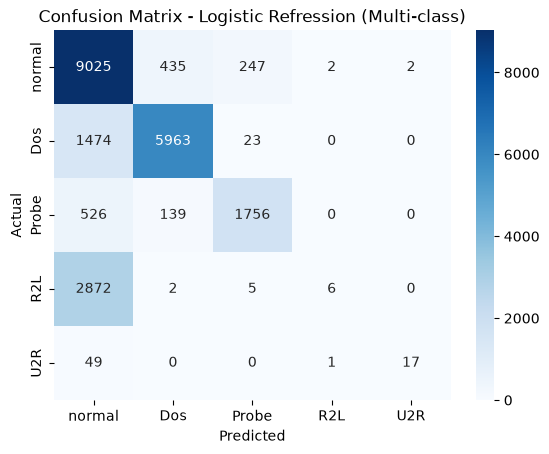

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cnfsn_mtrx_lr_multi, annot=True, fmt="d", cmap="Blues", xticklabels=["normal", "Dos", "Probe", "R2L", "U2R"], yticklabels=["normal", "Dos", "Probe", "R2L", "U2R"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Refression (Multi-class)")
plt.savefig("../images/confusion_matrix_lr_multiclass.png", dpi=150, bbox_inches="tight")

plt.show()

Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dec_tree_multi = DecisionTreeClassifier(random_state=42)
dec_tree_multi.fit(x_train, y_train)

print("Model Train")

Model Train


In [13]:
y_pred_dt_multi = dec_tree_multi.predict(x_test)

print(classification_report(y_test, y_pred_dt_multi))

              precision    recall  f1-score   support

         Dos       0.95      0.82      0.88      7460
       Probe       0.79      0.63      0.70      2421
         R2L       0.98      0.07      0.14      2885
         U2R       0.65      0.25      0.37        67
      normal       0.67      0.96      0.79      9711

    accuracy                           0.76     22544
   macro avg       0.81      0.55      0.58     22544
weighted avg       0.82      0.76      0.73     22544



confusion Matrix of decision tree

In [14]:
cm_dt_multi = confusion_matrix(y_test, y_pred_dt_multi, labels=["normal", "Dos", "Probe", "R2L", "U2R"])
print(cm_dt_multi)

[[9338   59  311    1    2]
 [1252 6129   79    0    0]
 [ 647  246 1528    0    0]
 [2647    0   16  215    7]
 [  44    0    2    4   17]]


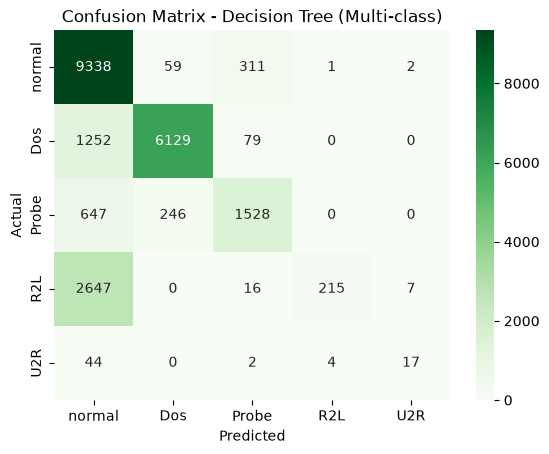

In [17]:
sns.heatmap(cm_dt_multi, annot=True, fmt="d", cmap="Greens", xticklabels=["normal", "Dos", "Probe", "R2L", "U2R"], yticklabels=["normal", "Dos", "Probe", "R2L", "U2R"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Multi-class)")
plt.savefig("../images/confusion_matrix_tree_multiclass", dpi=150, bbox_inches="tight")
plt.show()

Random Forest 

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_multi = RandomForestClassifier(random_state=42, n_jobs=1)
rf_multi.fit(x_train, y_train)

print("Model Train")

Model Train


In [20]:
y_pred_rf_multi = rf_multi.predict(x_test)
print(classification_report(y_test, y_pred_rf_multi))

              precision    recall  f1-score   support

         Dos       0.96      0.76      0.85      7460
       Probe       0.82      0.61      0.70      2421
         R2L       0.98      0.05      0.09      2885
         U2R       0.62      0.07      0.13        67
      normal       0.64      0.97      0.77      9711

    accuracy                           0.74     22544
   macro avg       0.81      0.49      0.51     22544
weighted avg       0.81      0.74      0.70     22544



confusion matrix

In [21]:
cm_rf_multi = confusion_matrix(y_test, y_pred_rf_multi, labels=["normal", "Dos", "Probe", "R2L", "U2R"])
print(cm_rf_multi)

[[9450   67  192    0    2]
 [1693 5646  121    0    0]
 [ 790  163 1468    0    0]
 [2738    0    4  142    1]
 [  59    0    0    3    5]]


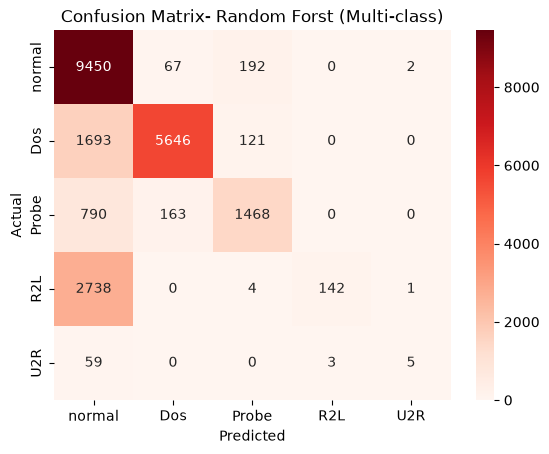

In [22]:
sns.heatmap(cm_rf_multi, annot=True, fmt="d", cmap="Reds", xticklabels=["normal", "Dos", "Probe", "R2L", "U2R"], yticklabels=["normal", "Dos", "Probe", "R2L", "U2R"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix- Random Forst (Multi-class)")
plt.savefig("../images/confusion_matrix_rndmfrst_multiclass.png", dpi=150, bbox_inches="tight")
plt.show()

Class weight tunning of Decision tree

In [23]:
dec_tree_multi_balanced = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dec_tree_multi_balanced.fit(x_train, y_train)

y_pred_balanced = dec_tree_multi_balanced.predict(x_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

         Dos       0.96      0.74      0.84      7460
       Probe       0.66      0.69      0.68      2421
         R2L       0.28      0.02      0.04      2885
         U2R       0.62      0.12      0.20        67
      normal       0.67      0.97      0.79      9711

    accuracy                           0.74     22544
   macro avg       0.64      0.51      0.51     22544
weighted avg       0.71      0.74      0.70     22544

